In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [15]:
# Import dataset from csv 
df_all = pd.read_csv('PreliminaryAnalysis.csv')
min_date = pd.to_datetime('2026-02-22 17:00:00')
df_all['time'] = pd.to_datetime(df_all['time'])
df = df_all.loc[df_all['time'] > min_date]
df = df.set_index("time")
df.head()


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-02-22 18:00:00,19.33,20.04,63.81,56.66,9.23,70.83,11.63,63.32
2026-02-22 19:00:00,19.07,19.65,65.78,60.08,8.89,70.79,10.33,66.01
2026-02-22 20:00:00,19.44,19.84,66.32,61.13,8.64,71.44,9.66,68.00
2026-02-22 21:00:00,19.26,19.54,65.34,61.40,8.44,75.14,9.39,71.99
2026-02-22 22:00:00,19.01,19.30,66.37,61.25,8.35,75.18,9.20,72.20


In [3]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k = 0.011497 # as found in parameters_indentification
dt = 1.0 # hours

In [4]:
def simulate_first_order_with_memory_solar(
    T0,
    Tout_ref_series,
    k,
    alpha,
    beta=0.85,
    dt=1.0
):
    """
    First-order thermal model with causal outdoor-warming proxy + memory term.

    T_{t+1} = T_t + [-k*(T_t - T_out) + alpha*S_t] * dt
    S_t = beta*S_{t-1} + max(dT_out/dt, 0)
    """

    idx = Tout_ref_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    S = np.zeros(len(idx), dtype=float)
    
    Tsim[0] = T0
    S[0] = 0.0

    Tout = Tout_ref_series.to_numpy(dtype=float)

    for i in range(1, len(idx)):
        # causal warming proxy from past step
        dTout_dt = (Tout[i-1] - Tout[i - 2]) / dt if i >= 2 else 0.0
        warming_proxy = max(dTout_dt, 0.0)
        
        # memory state
        S[i] = beta * S[i - 1] + warming_proxy
        
        T_prev = Tsim[i - 1]
        T_out_ref = Tout[i - 1]
        
        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + alpha * S[i - 1]) * dt

    return (pd.Series(Tsim, index=idx, name="Tsim_v4b"),
           pd.Series(S, index=idx, name="solar_memory_state")
    )

In [41]:
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"

k = 0.011497
dt = 1.0

df_sim = df.loc["2026-03-01":"2026-03-10", [column_in, column_out]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v4b"], df_sim["solar_state"] = simulate_first_order_with_memory_solar(
    T0=T0,
    Tout_ref_series=df_sim[column_out],
    k=k,
    alpha=0.05,   # initial guess
    beta=0.75,    # initial guess
    dt=dt
)

In [42]:
from scipy.optimize import minimize
import numpy as np

def objective_memory(params, Tin_series, Tout_series, dt=1.0):
    k, alpha, beta = params

    Tsim, _ = simulate_first_order_with_memory_solar(
        T0=Tin_series.iloc[0],
        Tout_ref_series=Tout_series,
        k=k,
        alpha=alpha,
        beta=beta,
        dt=dt
    )

    err = Tin_series.to_numpy(dtype=float) - Tsim.to_numpy(dtype=float)
    return np.mean(err**2)

In [43]:
initial_guess = [0.01, 0.10, 0.85]

result = minimize(
    objective_memory,
    x0=initial_guess,
    args=(df_sim[column_in], df_sim[column_out], 1.0),
    bounds=[(0.0001, 0.05), (0.0, 1.0), (0.0, 0.99)],
    method="L-BFGS-B"
)

k_opt, alpha_opt, beta_opt = result.x

print("k_opt     =", k_opt)
print("alpha_opt =", alpha_opt)
print("beta_opt  =", beta_opt)
print("objective =", result.fun)

k_opt     = 0.008751623065105341
alpha_opt = 0.04581657743776372
beta_opt  = 0.6846954147566082
objective = 0.1944006430270682


In [44]:
df_sim["Tsim_fit"], df_sim["S_fit"] = simulate_first_order_with_memory_solar(
    T0=df_sim[column_in].iloc[0],
    Tout_ref_series=df_sim[column_out],
    k=k_opt,
    alpha=alpha_opt,
    beta=beta_opt,
    dt=1.0
)

In [46]:
def compute_metrics(y_true, y_pred):
    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mbe = np.mean(err)   # mean bias error
    return mae, rmse, mbe

mae_fit, rmse_fit, mbe_fit = compute_metrics(
    df_sim[column_in].to_numpy(dtype=float),
    df_sim["Tsim_fit"].to_numpy(dtype=float)
)

print(f"Fitted model -> MAE:  {mae_fit:.3f} °C")
print(f"Fitted model -> RMSE: {rmse_fit:.3f} °C")
print(f"Fitted model -> MBE:  {mbe_fit:.3f} °C")

Fitted model -> MAE:  0.344 °C
Fitted model -> RMSE: 0.441 °C
Fitted model -> MBE:  0.012 °C


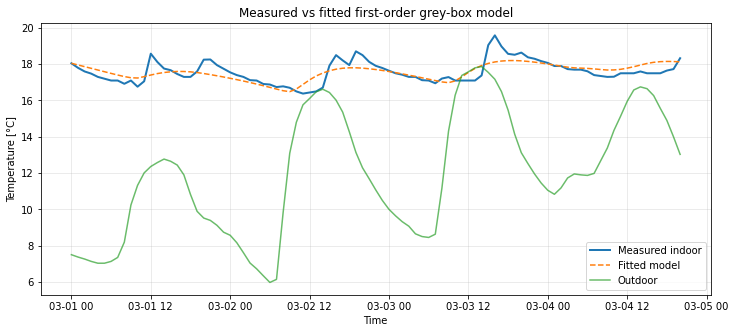

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_fit"], label="Fitted model", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Outdoor", alpha=0.7)

plt.title("Measured vs fitted first-order grey-box model")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

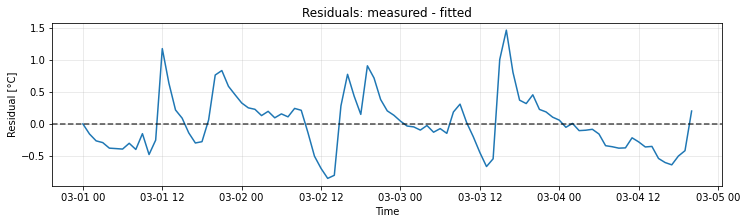

In [48]:
df_sim["residual_fit"] = df_sim[column_in] - df_sim["Tsim_fit"]

plt.figure(figsize=(12, 3))
plt.plot(df_sim.index, df_sim["residual_fit"])
plt.axhline(0, color="k", linestyle="--", alpha=0.7)

plt.title("Residuals: measured - fitted")
plt.xlabel("Time")
plt.ylabel("Residual [°C]")
plt.grid(True, alpha=0.3)
plt.show()

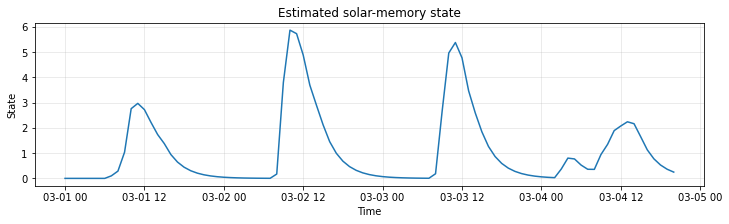

In [49]:
plt.figure(figsize=(12, 3))
plt.plot(df_sim.index, df_sim["S_fit"])
plt.title("Estimated solar-memory state")
plt.xlabel("Time")
plt.ylabel("State")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
print(f"k_opt     = {k_opt:.5f} 1/h")
print(f"alpha_opt = {alpha_opt:.5f}")
print(f"beta_opt  = {beta_opt:.5f}")
print(f"tau_opt   = {1.0 / k_opt:.2f} h")

k_opt     = 0.00875 1/h
alpha_opt = 0.04582
beta_opt  = 0.68470
tau_opt   = 114.26 h


In [51]:
summary = pd.DataFrame({
    "parameter": ["k_opt", "tau_opt_h", "alpha_opt", "beta_opt", "MAE", "RMSE", "MBE"],
    "value": [k_opt, 1.0 / k_opt, alpha_opt, beta_opt, mae_fit, rmse_fit, mbe_fit]
})

summary

,parameter,value
0,k_opt,0.008752
1,tau_opt_h,114.264519
2,alpha_opt,0.045817
3,beta_opt,0.684695
4,MAE,0.343744
5,RMSE,0.440909
6,MBE,0.011596
